# Titanic Survival Prediction - Classification Analysis

**Dataset:** Titanic Dataset (Kaggle)
**Source:** https://www.kaggle.com/datasets/yasserh/titanic-dataset

## Problem Statement
Build at least 3 classification models (Logistic Regression, Decision Tree, Random Forest) to predict the target class (`Survived`). Select the best-performing model and justify the choice using Accuracy, Precision, Recall, F1-score, and a confusion matrix. ROC-AUC is included as an additional comparison metric.

## Dataset Description
The dataset contains Titanic passenger records with the following columns:
- `PassengerId` — unique passenger identifier
- `Survived` — **target variable**: 0 = did not survive, 1 = survived
- `Pclass` — ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- `Name` — passenger name
- `Sex` — male / female
- `Age` — age in years (contains missing values)
- `SibSp` — number of siblings/spouses aboard
- `Parch` — number of parents/children aboard
- `Ticket` — ticket number
- `Fare` — ticket fare paid
- `Cabin` — cabin number (mostly missing)
- `Embarked` — port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score)

## Step 2: Load the Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3: Inspect Data Structure

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 4: Check Missing Values & Duplicates

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## Step 5: Handle Missing Values

In [7]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin - too many missing values to be useful
df = df.drop('Cabin', axis=1)

# Confirm no missing values remain
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Data Cleaning Summary
- 891 rows, no duplicates found
- `Age` had 177 missing values → filled with median age
- `Embarked` had 2 missing values → filled with mode (most common port)
- `Cabin` had 687 missing values (77% of the column) → dropped entirely, too sparse to be useful
- `Fare` shows a known extreme outlier (max ~512), retained since it reflects genuine premium ticket prices, not a data error

## Step 6: EDA - Target Distribution

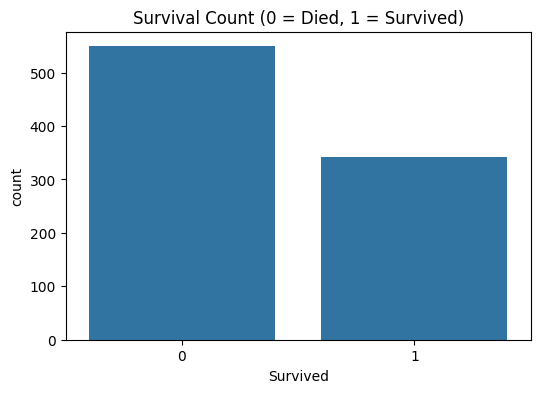

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()

print(df['Survived'].value_counts(normalize=True))

- Survival is moderately imbalanced: 61.6% did not survive, 38.4% survived
- This makes Accuracy alone a misleading metric — a model predicting "died" for everyone would still score ~62% accuracy without learning anything useful, which is why Precision, Recall, and F1-score matter here

## Step 7: EDA - Survival by Key Features

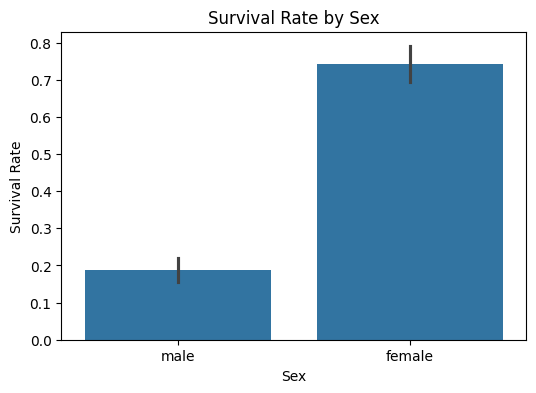

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

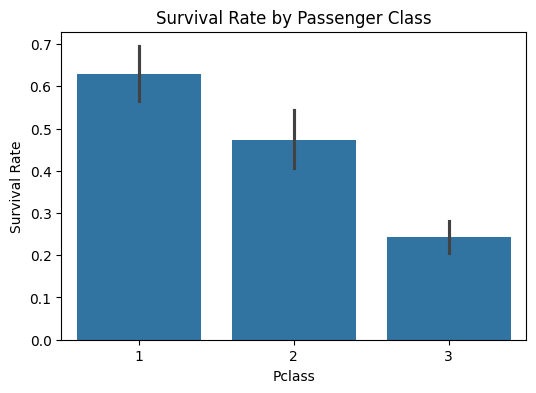

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

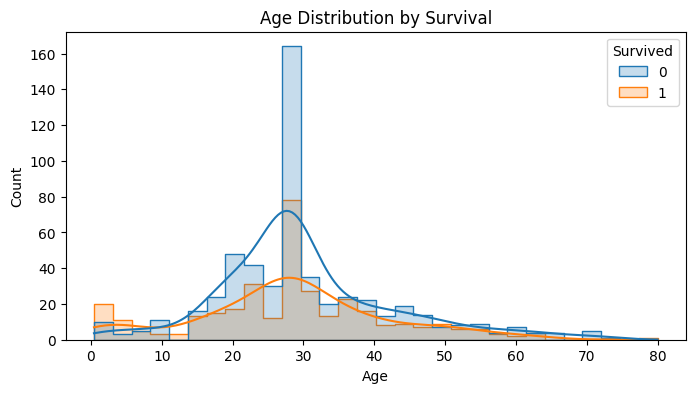

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, element='step')
plt.title('Age Distribution by Survival')
plt.show()

- **Sex** shows a dramatic survival gap: females survived at roughly 74%, males at roughly 19% — the "women first" evacuation policy is clearly visible in the data
- **Pclass** shows a clear gradient: 1st class survival (~63%) is much higher than 3rd class (~24%), reflecting unequal access to lifeboats/decks
- **Age** shows a modest effect: young children have a relatively higher survival rate than adults, though the effect is much smaller than Sex or Pclass

## Step 8: Feature Engineering & Selection

In [12]:
# Family size feature: combine SibSp + Parch + self
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Drop columns that aren't useful for prediction as-is
df_model = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

df_model.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1


## Step 9: Encode Categorical Variables

In [13]:
df_encoded = pd.get_dummies(df_model, columns=['Sex', 'Embarked'], drop_first=True)

bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,1,0,1
1,1,1,38.0,1,0,71.2833,2,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,1
3,1,1,35.0,1,0,53.1000,2,0,0,1
4,0,3,35.0,0,0,8.0500,1,1,0,1


## Step 10: Train-Test Split

In [14]:
X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (712, 9)
Test set: (179, 9)


## Step 11: Feature Scaling

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 12: Build Logistic Regression Model

In [16]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


## Step 13: Build Decision Tree Model

In [17]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree trained successfully")

Decision Tree trained successfully


## Step 14: Build Random Forest Model

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest trained successfully")

Random Forest trained successfully


## Step 15: Compare Metrics (Accuracy, Precision, Recall, F1)

In [19]:
def evaluate_classifier(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate_classifier(y_test, y_pred_log, 'Logistic Regression'),
    evaluate_classifier(y_test, y_pred_dt, 'Decision Tree'),
    evaluate_classifier(y_test, y_pred_rf, 'Random Forest')
])

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,Decision Tree,0.759777,0.740741,0.579710,0.650407
2,Random Forest,0.815642,0.860000,0.623188,0.722689


- Random Forest achieves the highest Accuracy (81.6%) and Precision (86.0%), making it the most reliable when it predicts survival
- Logistic Regression achieves the highest Recall (66.7%), meaning it catches more actual survivors, at the cost of some false positives
- Decision Tree performs weakest across all four metrics, likely due to its single-tree structure being less robust than an ensemble
- F1-Score is nearly tied between Logistic Regression and Random Forest, reflecting their precision/recall tradeoff

 ## Step 16: Confusion Matrices

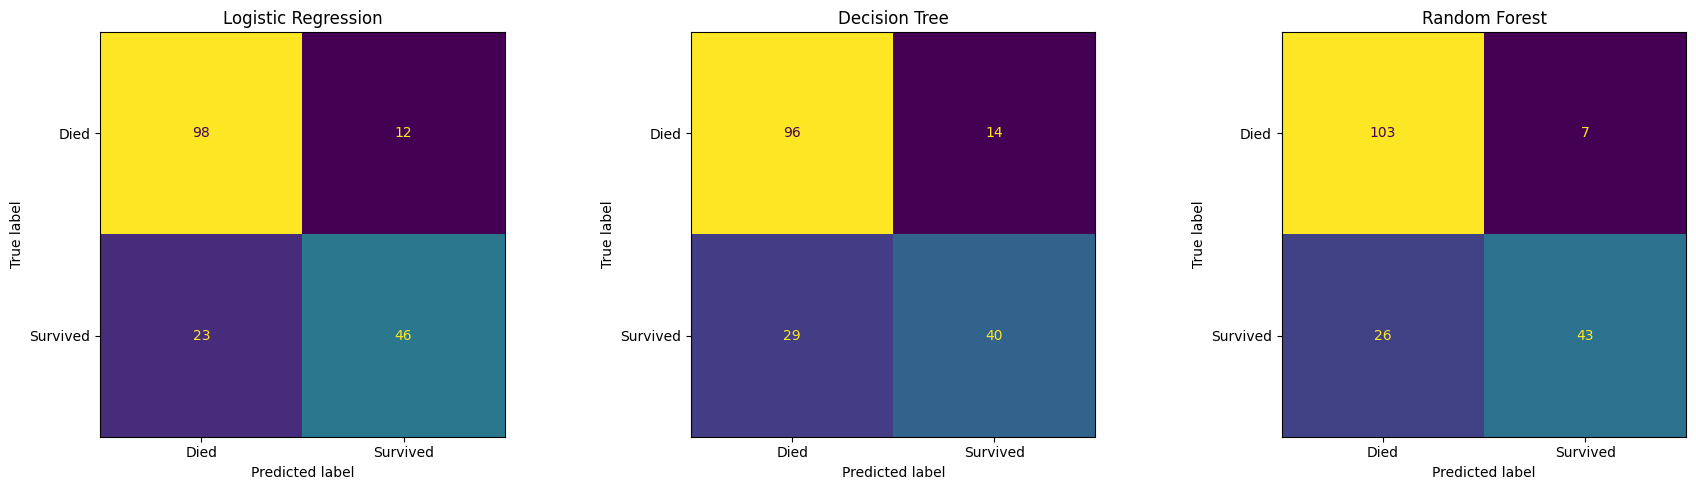

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models_preds = [
    ('Logistic Regression', y_pred_log),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf)
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

- Confusion matrices confirm the metric tradeoffs: Random Forest has the fewest false positives (7), explaining its highest Precision
- Logistic Regression has slightly fewer false negatives (23 vs. 26 for Random Forest), explaining its higher Recall
- Decision Tree has the most errors overall (14 false positives + 29 false negatives = 43 total mistakes), consistent with its weaker metrics across the board

## Step 17: ROC-AUC Comparison

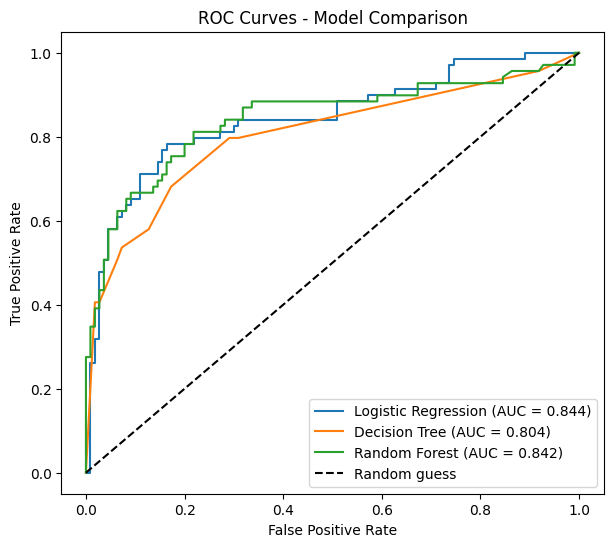

In [21]:
plt.figure(figsize=(7,6))

# Logistic Regression - use scaled test data and probability scores
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')

# Decision Tree
y_prob_dt = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.show()

- ROC-AUC confirms Logistic Regression (0.844) and Random Forest (0.842) are nearly tied and both meaningfully outperform Decision Tree (0.804)
- All three models rank predictions far better than random guessing (AUC = 0.5), confirming real predictive signal was learned

## Step 18: Conclusion

## Conclusion

Across every metric, **Decision Tree is consistently the weakest model** (lowest Accuracy, Precision, F1, and AUC), so it is ruled out first.

The real decision is between **Logistic Regression** and **Random Forest**, which perform very similarly overall:

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 0.804 | **0.816** |
| Precision | 0.793 | **0.860** |
| Recall | **0.667** | 0.623 |
| F1-Score | **0.724** | 0.723 |
| ROC-AUC | **0.844** | 0.842 |

**Random Forest is selected as the best-performing model overall**, for these reasons:
- It achieves the highest Accuracy and by far the highest Precision (86.0% vs. 79.3%) — when it predicts someone survived, it is right much more often, meaning fewer false alarms
- Its Recall and AUC are only marginally lower than Logistic Regression's (a difference of a few percentage points), while its Precision advantage is substantial
- As an ensemble of 100 trees, Random Forest is generally more robust to overfitting and noise than a single Decision Tree, and does not rely on the linearity assumptions that Logistic Regression makes about the relationship between features and the outcome

**When Logistic Regression might be preferred instead:** if the priority were to minimize missed survivors (maximize Recall) — for example, in a safety-critical context where failing to identify a survivor is worse than a false alarm — Logistic Regression's higher Recall (66.7% vs. 62.3%) would make it the better choice. This tradeoff between Precision and Recall is the central nuance of this comparison, and the "best" model ultimately depends on which type of error matters more for the use case.